dx_ref = 0.01010, dt_sc = 0.00200, strips = 50
Generating FD reference...
Run 01/05 | seed =   0 | points = 4438 | mean err = 2.339e-03 | max err = 2.549e-02
Run 02/05 | seed =   1 | points = 4470 | mean err = 2.156e-03 | max err = 2.110e-02
Run 03/05 | seed =   2 | points = 4517 | mean err = 1.325e-03 | max err = 2.698e-02
Run 04/05 | seed =   3 | points = 4504 | mean err = 1.828e-03 | max err = 4.879e-02
Run 05/05 | seed =   4 | points = 4562 | mean err = 1.548e-03 | max err = 2.269e-02

UQ summary across runs
points per run: mean = 4498.2, min = 4438, max = 4562
mean error over runs: mean = 1.839e-03, std = 3.741e-04
max error over runs: mean = 2.901e-02, std = 1.010e-02


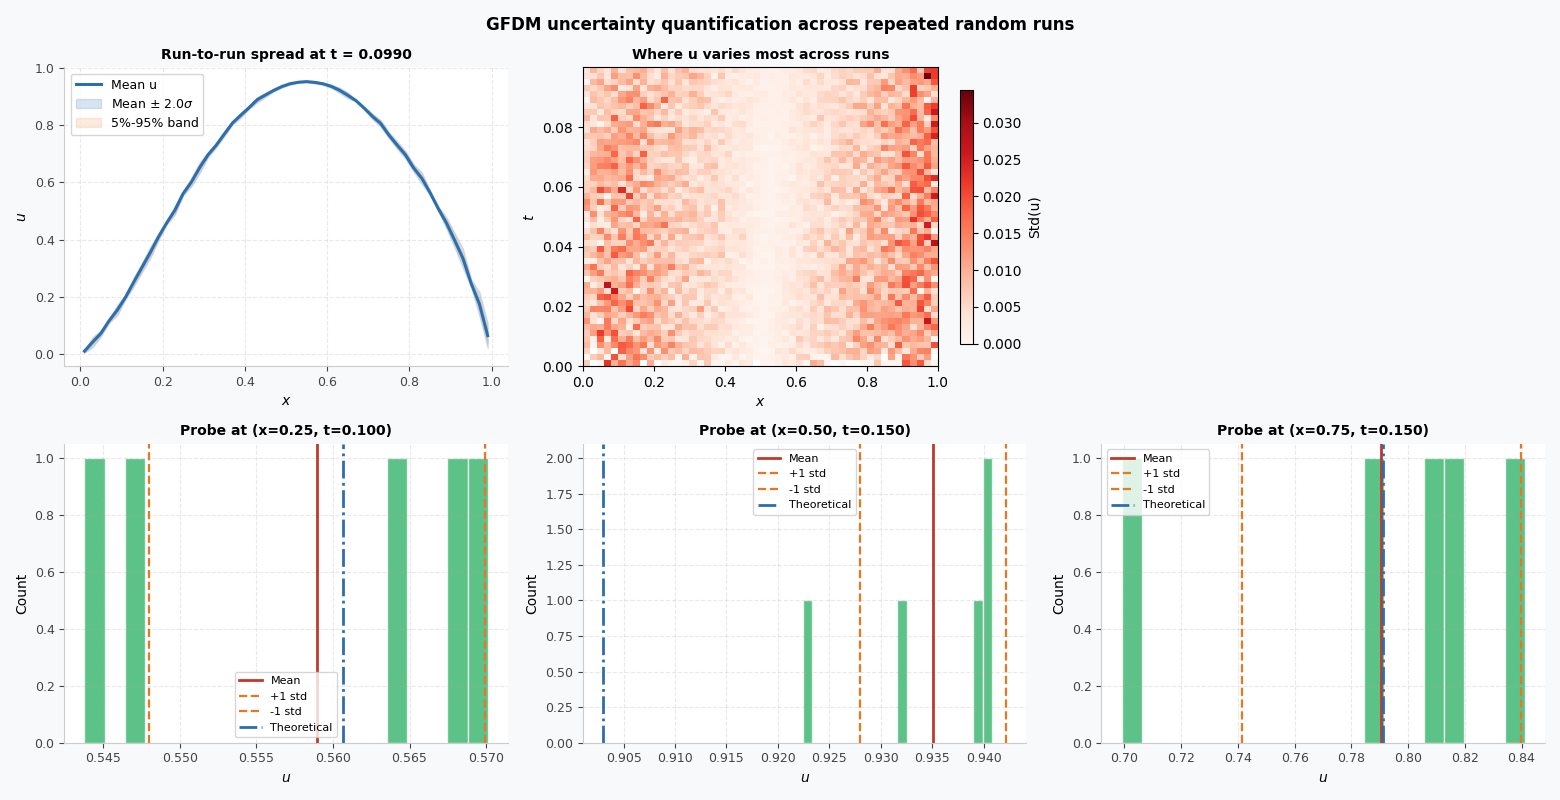

In [ ]:
import importlib
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt

from Plots import gfdm_uq_plots as gfdm_uq_plots_module
importlib.reload(gfdm_uq_plots_module)
plot_uq_dashboard = gfdm_uq_plots_module.plot_uq_dashboard


# Parameters
alpha = 0.05
c = 0.5
T = 0.2

nx_sc = 100
spawn_per_point = 2
max_candidates = 1000

n_exact = 8
box_x0 = 0.15
box_t0 = 0.01
box_xmax = 0.1 / 2
box_tmax = T
box_grow = 1.5
cond_max = 1e8

dt_sc = 0.002
dx_ref = 1.0 / (nx_sc - 1)
min_dist = 0.4 * dx_ref

# UQ controls
n_runs = 20
base_seed = 0
uq_slice_t = 0.15
uq_probes = [(0.25, 0.10), (0.50, 0.15), (0.75, 0.15)]

t_strips = np.arange(0, T + dt_sc, dt_sc)
print(f"dx_ref = {dx_ref:.5f}, dt_sc = {dt_sc:.5f}, strips = {len(t_strips)-1}")


def u_true(x, t):
    k = c / (2.0 * alpha)

    def f(p):
        if p == 0:
            return (1.0 - np.exp(-k)) / k if k > 1e-10 else 1.0
        return k * (1.0 - (-1) ** p * np.exp(-k)) / (k**2 + (p * np.pi) ** 2)

    x_arr = np.asarray(x, dtype=float)
    v = np.zeros_like(x_arr)
    for n in range(1, 31):
        v += (f(n - 1) - f(n + 1)) * np.exp(-alpha * (n * np.pi) ** 2 * t) * np.sin(n * np.pi * x_arr)
    result = np.exp(k * x_arr - k**2 * alpha * t) * v
    return float(result) if np.ndim(x) == 0 else result


def generate_fd_reference(nx=200, dt=1e-4):
    x = np.linspace(0, 1, nx)
    dx = x[1] - x[0]
    lam = alpha * dt / dx**2

    if lam > 0.3:
        print(f"Warning: scheme may be unstable (lambda = {lam:.3f})")

    nt = int(T / dt) + 1
    U = np.zeros((nt, nx))
    U[0] = u_true(x, 0)

    for k in range(nt - 1):
        U[k + 1, 2:-2] = (
            U[k, 2:-2]
            + lam / 12 * (
                -U[k, 4:]
                + 16 * U[k, 3:-1]
                - 30 * U[k, 2:-2]
                + 16 * U[k, 1:-3]
                - U[k, :-4]
            )
            - c * dt / (2 * dx) * (U[k, 3:-1] - U[k, 1:-3])
        )

        U[k + 1, 1] = U[k, 1] + lam * (U[k, 2] - 2 * U[k, 1] + U[k, 0]) - c * dt / (2 * dx) * (U[k, 2] - U[k, 0])
        U[k + 1, -2] = U[k, -2] + lam * (U[k, -1] - 2 * U[k, -2] + U[k, -3]) - c * dt / (2 * dx) * (U[k, -1] - U[k, -3])
        U[k + 1, 0] = 0.0
        U[k + 1, -1] = 0.0

    return x, np.arange(nt) * dt, U


print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference()


def fd_interp(xq, tq):
    ix = np.clip(np.searchsorted(x_fd, xq) - 1, 0, len(x_fd) - 2)
    it = np.clip(np.searchsorted(t_fd, tq) - 1, 0, len(t_fd) - 2)

    tx = (xq - x_fd[ix]) / (x_fd[ix + 1] - x_fd[ix])
    tt = (tq - t_fd[it]) / (t_fd[it + 1] - t_fd[it])

    return (
        (1 - tt) * (1 - tx) * U_fd[it, ix]
        + (1 - tt) * tx * U_fd[it, ix + 1]
        + tt * (1 - tx) * U_fd[it + 1, ix]
        + tt * tx * U_fd[it + 1, ix + 1]
    )


def solve_weights(dx_i, dt_i):
    A = np.array([
        np.ones(len(dx_i)),
        dx_i - c * dt_i,
        0.5 * dx_i**2 + alpha * dt_i,
        (1 / 6) * dx_i**3 + alpha * dx_i * dt_i - alpha * c * dt_i**2,
    ])
    b = np.array([1.0, 0.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    w = np.linalg.lstsq(A, b, rcond=None)[0]
    return w, cond


def far_from_existing(xc, tc, visited):
    for x, t, _ in visited:
        if abs(x - xc) < min_dist and abs(t - tc) < dt_sc * 0.5:
            return False
    return True


def spawn_candidates(xi, ti, rng):
    new = []
    for _ in range(spawn_per_point):
        xc = xi + rng.uniform(-box_x0, box_x0)
        tc = ti + rng.uniform(0.0, box_t0)
        if 0.0 <= xc <= 1.0 and tc <= T:
            new.append((xc, tc))
    return new


def find_neighbours(x_star, t_star, visited):
    bx, bt = box_x0, box_t0

    while True:
        nb = [
            p for p in visited
            if abs(p[0] - x_star) <= bx and 0 < (t_star - p[1]) <= bt
        ]

        if len(nb) >= n_exact:
            nb.sort(key=lambda p: (p[0] - x_star) ** 2 + (p[1] - t_star) ** 2)
            return nb[:n_exact]

        bx = min(bx * box_grow, box_xmax)
        bt = min(bt * box_grow, box_tmax)
        if bx >= box_xmax and bt >= box_tmax:
            return None


def run_gfdm_once(seed=None):
    rng = np.random.default_rng(seed)
    visited = []
    point_data = []
    candidates = []

    x_ic = np.linspace(0, 1, nx_sc)
    for xi in x_ic:
        visited.append((xi, 0.0, u_true(xi, 0.0)))

    t_bc = np.arange(0, T + dt_sc, dt_sc)
    for t in t_bc:
        visited.append((0.0, t, 0.0))
        visited.append((1.0, t, 0.0))

    for xi, ti, ui in visited:
        if abs(xi) < 1e-12 or abs(xi - 1.0) < 1e-12:
            continue
        candidates.extend(spawn_candidates(xi, ti, rng))

    while candidates:
        if len(candidates) > max_candidates:
            candidates = candidates[-max_candidates:]

        idx = int(rng.integers(len(candidates)))
        x_star, t_star = candidates.pop(idx)

        if not far_from_existing(x_star, t_star, visited):
            continue

        if abs(x_star) < 1e-12 or abs(x_star - 1.0) < 1e-12:
            visited.append((x_star, t_star, 0.0))
            continue

        nb = find_neighbours(x_star, t_star, visited)
        if nb is None:
            continue

        nb_pts = np.array(nb)
        dx_i = nb_pts[:, 0] - x_star
        dt_i = nb_pts[:, 1] - t_star
        u_i = nb_pts[:, 2]

        if np.min(dx_i) * np.max(dx_i) > 0:
            continue

        span = np.max(dx_i) - np.min(dx_i)
        if span < 0.9 * dx_ref:
            continue

        w, cond = solve_weights(dx_i, dt_i)
        if cond > cond_max:
            continue

        u_hat = w @ u_i
        visited.append((x_star, t_star, u_hat))
        candidates.extend(spawn_candidates(x_star, t_star, rng))

        u_ref = fd_interp(x_star, t_star)
        point_data.append({
            "x": x_star,
            "t": t_star,
            "u": u_hat,
            "err": abs(u_hat - u_ref),
            "w1": np.sum(np.abs(w)),
            "cond": cond,
            "nb_x": nb_pts[:, 0].copy(),
            "nb_t": nb_pts[:, 1].copy(),
            "nb_u": nb_pts[:, 2].copy(),
            "box_x": np.max(np.abs(dx_i)),
            "box_t": np.max(np.abs(dt_i)),
        })

    errs = np.array([p["err"] for p in point_data], dtype=float)
    return {
        "seed": seed,
        "point_data": point_data,
        "visited": visited,
        "x_ic": x_ic,
        "t_bc": t_bc,
        "mean_err": float(np.mean(errs)) if len(errs) else np.nan,
        "max_err": float(np.max(errs)) if len(errs) else np.nan,
        "n_points": len(point_data),
    }


all_runs = []
for run_id in range(n_runs):
    seed = base_seed + run_id
    run = run_gfdm_once(seed=seed)
    all_runs.append(run)
    print(
        f"Run {run_id + 1:02d}/{n_runs:02d} | seed = {seed:3d} | "
        f"points = {run['n_points']:4d} | mean err = {run['mean_err']:.3e} | max err = {run['max_err']:.3e}"
    )


runs_point_data = [run["point_data"] for run in all_runs]
point_counts = np.array([run["n_points"] for run in all_runs], dtype=int)
mean_errors = np.array([run["mean_err"] for run in all_runs], dtype=float)
max_errors = np.array([run["max_err"] for run in all_runs], dtype=float)

print("\nUQ summary across runs")
print(f"points per run: mean = {point_counts.mean():.1f}, min = {point_counts.min()}, max = {point_counts.max()}")
print(f"mean error over runs: mean = {np.nanmean(mean_errors):.3e}, std = {np.nanstd(mean_errors):.3e}")
print(f"max error over runs: mean = {np.nanmean(max_errors):.3e}, std = {np.nanstd(max_errors):.3e}")


# Keep last-run variables available for any follow-up diagnostics you already use.
last_run = all_runs[-1]
point_data = last_run["point_data"]
visited = last_run["visited"]
x_ic = last_run["x_ic"]
t_bc = last_run["t_bc"]

px = np.array([p["x"] for p in point_data])
pt = np.array([p["t"] for p in point_data])
pu = np.array([p["u"] for p in point_data])
perr = np.array([p["err"] for p in point_data])
cond_vals = np.array([p["cond"] for p in point_data])
w1_vals = np.array([p["w1"] for p in point_data])
true_vals = np.array([u_true(p["x"], p["t"]) for p in point_data])

tol_bc = 1e-12
bc_x = np.array([p[0] for p in visited if abs(p[0]) < tol_bc or abs(p[0] - 1.0) < tol_bc])
bc_t = np.array([p[1] for p in visited if abs(p[0]) < tol_bc or abs(p[0] - 1.0) < tol_bc])
ic_t = np.zeros(len(x_ic))


plot_uq_dashboard(
    runs_point_data,
    t_value=uq_slice_t,
    probes=uq_probes,
    nx=50,
    nt=50,
    bins=20,
    u_true=u_true,
)
plt.show()
